In [ ]:
!wget -q -r -N -c -np https://physionet.org/files/mimic-iv-demo/2.2/
BASE = "physionet.org/files/mimic-iv-demo/2.2/hosp/"

import pandas as pd
import matplotlib.pyplot as plt

labs  = pd.read_csv(BASE + "labevents.csv.gz")
items = pd.read_csv(BASE + "d_labitems.csv.gz")
adm   = pd.read_csv(BASE + "admissions.csv.gz", parse_dates=["admittime", "dischtime"])

glucose_items = items[(items["label"] == "Glucose") & (items["fluid"] == "Blood")]
g = labs[labs["itemid"].isin(glucose_items["itemid"])].copy()
g = g.dropna(subset=["hadm_id", "valuenum"])
g = g[(g["valuenum"] >= 10) & (g["valuenum"] <= 1500)]
print(len(g), "glucose readings kept")

2538 glucose readings kept


In [ ]:
g["low"]  = g["valuenum"] < 70
g["high"] = g["valuenum"] > 180

per_stay = g.groupby("hadm_id").agg(
    n_readings   = ("valuenum", "size"),
    mean_glucose = ("valuenum", "mean"),
    pct_low      = ("low", "mean"),
    pct_high     = ("high", "mean"),
).reset_index()
per_stay["pct_low"]  = per_stay["pct_low"]  * 100
per_stay["pct_high"] = per_stay["pct_high"] * 100
per_stay = per_stay[per_stay["n_readings"] >= 3]

df = per_stay.merge(adm[["hadm_id", "admittime", "dischtime", "hospital_expire_flag"]], on="hadm_id")
df["los_days"] = (df["dischtime"] - df["admittime"]).dt.total_seconds() / 86400
df["any_low"]  = df["pct_low"] > 0

print(len(df), "hospital stays")
print("Stays with at least one low reading:", int(df["any_low"].sum()))
print(df.groupby("any_low")["los_days"].median().round(1))
print(df[["pct_high", "pct_low", "mean_glucose", "los_days"]].corr(method="spearman").round(2))

199 hospital stays
Stays with at least one low reading: 32
any_low
False     5.9
True     10.3
Name: los_days, dtype: float64
              pct_high  pct_low  mean_glucose  los_days
pct_high          1.00     0.05          0.85      0.05
pct_low           0.05     1.00         -0.09      0.17
mean_glucose      0.85    -0.09          1.00      0.02
los_days          0.05     0.17          0.02      1.00


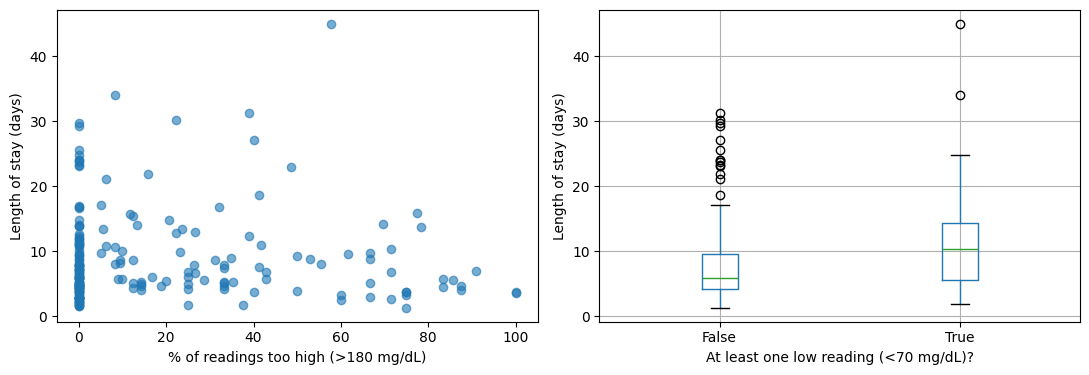

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(df["pct_high"], df["los_days"], alpha=0.6)
ax[0].set_xlabel("% of readings too high (>180 mg/dL)")
ax[0].set_ylabel("Length of stay (days)")
df.boxplot(column="los_days", by="any_low", ax=ax[1])
ax[1].set_xlabel("At least one low reading (<70 mg/dL)?")
ax[1].set_ylabel("Length of stay (days)")
plt.suptitle("")
ax[1].set_title("")
plt.tight_layout()
plt.show()